In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import spacy
import torch
import torch.nn as nn
import torch.utils as utils
import torch.optim as optim
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import tokenizers
import matplotlib.pyplot as plt

from PIL import Image
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Data

In [3]:
root_dir = '/kaggle/input/flickr-image-dataset/flickr30k_images/'
img_dir = root_dir + 'flickr30k_images'
anno_dir = root_dir + 'results.csv'

In [4]:
# Fixing the results.csv file
with open(anno_dir, 'r') as results, open('/kaggle/working/new_results.csv', 'w') as new_results:
    for line in results:
        if len(line.split('|')) != 3:
            line = line.replace("   ", "|  ")
        new_results.write(line)
        
df = pd.read_csv('/kaggle/working/new_results.csv', sep='|')
df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


## Vocabulary

In [5]:
spacy_end = spacy.load("en_core_web_sm")

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0:"<PAD>", 1:"<SOS>", 2:"<EOS>", 3:"<UNK>"}
        self.stoi = {"<PAD>":0, "<SOS>":1, "<EOS>":2, "<UNK>":3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        return [token.text.lower() for token in spacy_end.tokenizer(text)]

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4 # continue from the 4 special tokens

        # Store words and their frequencies
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1
                else:
                    frequencies[word] += 1

                # Adding word to the vocabulary if its frequencies == freq_threshold
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

In [6]:
# Initialize vocabulary
vocab = Vocabulary(5)
vocab.itos[0]

'<PAD>'

In [7]:
# Build vocabulary then check if new words were added
vocab.build_vocabulary(df[' comment'].tolist())
vocab.itos[13]

'standing'

## Dataset

In [8]:
class FlickrDataset(utils.data.Dataset):
    def __init__(self, root_dir, img_caption_df, transform=None, mode='train', vocab=None):
        self.root_dir = root_dir
        self.df = img_caption_df
        self.mode = mode
        self.vocab = vocab
        self.random_seed = 42

        # Split into train/test/val = 0.8/0.1/0.1
        train_df, temp_df = train_test_split(self.df, test_size=0.2, random_state=self.random_seed)

        if self.mode == 'train':
            self.df = train_df
        elif self.mode == 'val':
            val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=self.random_seed)
            self.df = val_df
        else:
            val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=self.random_seed)
            self.df = test_df
            
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        caption = row[' comment']
        img_id = row['image_name']

        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])
        # <SOS> This is the caption. <EOS>
        
        return img, torch.tensor(numericalized_caption), img_id

In [9]:
class Collate():
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        # imgs = [item[0].unsqueeze(0) for item in batch]
        # imgs = torch.cat(imgs, dim=0)
        imgs = torch.stack([item[0] for item in batch], dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)

        img_ids = [item[2] for item in batch]
        
        return imgs, targets, img_ids

In [10]:
def get_loader(
    root_folder,
    df,
    transform,
    vocab,
    batch_size=32,
    num_workers=4,
    shuffle=True,
    pin_memory=True,
):
    # Create train/val/test datasets
    train_dataset = FlickrDataset(root_folder, df, transform=transform, vocab=vocab)
    val_dataset = FlickrDataset(root_folder, df, transform=None, mode='val', vocab=vocab)
    test_dataset = FlickrDataset(root_folder, df, transform=None, mode='test', vocab=vocab)
    pad_idx = vocab.stoi["<PAD>"]

    # Create train loader
    train_loader = utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=Collate(pad_idx=pad_idx),
    )

    # Create val loader
    val_loader = utils.data.DataLoader(
        dataset=val_dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=Collate(pad_idx=pad_idx),
    )
    
    # Create test loader
    test_loader = utils.data.DataLoader(
        dataset=test_dataset,
        batch_size=1,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=Collate(pad_idx=pad_idx),
    )

    return train_loader, val_loader, test_loader, train_dataset

# Encoder

In [11]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        inception = models.inception_v3(weights='DEFAULT', aux_logits=True)
        modules = list(inception.children())[:-1]   # remove last fc
        # self.cnn = nn.Sequential(*modules)
        self.cnn = nn.Sequential(
            inception.Conv2d_1a_3x3,
            inception.Conv2d_2a_3x3,
            inception.Conv2d_2b_3x3,
            nn.MaxPool2d(3, stride=2),
            inception.Conv2d_3b_1x1,
            inception.Conv2d_4a_3x3,
            nn.MaxPool2d(3, stride=2),
            inception.Mixed_5b,
            inception.Mixed_5c,
            inception.Mixed_5d,
            inception.Mixed_6a,
            inception.Mixed_6b,
            inception.Mixed_6c,
            inception.Mixed_6d,
            inception.Mixed_6e,
            inception.Mixed_7a,
            inception.Mixed_7b,
            inception.Mixed_7c,
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        self.linear = nn.Linear(2048, embed_size)

        # Freeze CNN if specified
        for name, param in self.cnn.named_parameters():
            if "fc.weight" in name or "fc.bias" in name:
                param.requires_grad = True
            else:
                param.requires_grad = self.train_CNN

    # This forward will return a 
    def forward(self, images):
        features = self.cnn(images) # (B, 2028, H, W)
        features = self.adaptive_pool(features) # (B, 2048, 8, 8)
        features = features.permute(0, 2, 3, 1) # (B, 8, 8, 2048)
        features = features.view(features.size(0), -1, 2048) # (B, 64, 2048)
        features = self.linear(features) # (B, 64, embed_size)
        return features

In [12]:
# encoder = EncoderCNN(256)
# imgs = torch.randn(32, 3, 299, 299)
# features = encoder(imgs)
# print(features.shape)

# Decoder

In [13]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_attn = nn.Linear(encoder_dim, attention_dim)
        self.decoder_attn = nn.Linear(decoder_dim, attention_dim)
        self.full_attn = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, hidden_state):
        e_attn = self.encoder_attn(encoder_out) # (B, 8x8, embed_size)
        d_attn = self.decoder_attn(hidden_state).unsqueeze(1)
        # d_attn = d_attn.permute(1, 0, 2)
        # print(d_attn.shape)
        attn = self.full_attn(self.relu(e_attn + d_attn)).squeeze(2)  # (B, num_pixels)
        alpha = self.softmax(attn)                             # (B, num_pixels)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (B, encoder_dim)
        return context, alpha

In [14]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        encoder_dim = 256
        attn_dim = 256
        self.num_layers = num_layers
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.attn = Attention(encoder_dim, hidden_size, attn_dim)
        self.lstm = nn.LSTM(embed_size+encoder_dim, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions, teacher_forcing_ratio=0.5):
        # Features shape: (Batch, 8x8, 256)
        # Captions shape: (Batch, Caption's length)
        batch_size = features.size(0)
        num_pixels = features.size(1)
        vocab_size = self.linear.out_features

        embeddings = self.embed(captions) # (B, max_len, embed_size)

        h, c = (torch.zeros(self.num_layers, batch_size, self.lstm.hidden_size, device=features.device),
                torch.zeros(self.num_layers, batch_size, self.lstm.hidden_size, device=features.device))

        outputs = torch.zeros(batch_size, captions.size(1), vocab_size,device=features.device)

        # Iterate though each timestep(word) in the caption
        for t in range(captions.size(1)):
            
            if t == 0 or torch.rand(1, device=features.device) < teacher_forcing_ratio:
                word_embed = embeddings[:, t, :]
            else:
                prev_word = outputs[:, t-1, :].argmax(dim=1)
                word_embed = self.embed(prev_word)

            h_top = h[-1]
            context, alpha = self.attn(features, h_top)

            lstm_input = torch.cat([word_embed, context], dim=1)
            lstm_input = lstm_input.unsqueeze(1)
            lstm_out, (h, c) = self.lstm(lstm_input, (h, c))
            
            out = self.linear(self.dropout(lstm_out))
            out = out.squeeze(1)
            
            outputs[:, t, :] = out

        return outputs

# Model

In [15]:
class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image_beam_search(self, image, vocabulary, max_length=50, beam_size=4, start_token="<SOS>", end_token="<EOS>"):
        with torch.no_grad():
            # Encode image → features (1, num_pixels, encoder_dim)
            features = self.encoderCNN(image.unsqueeze(0))
            
            batch_size = features.size(0)
            device = features.device
    
            # Init hidden state
            h, c = (torch.zeros(self.decoderRNN.num_layers, batch_size, self.decoderRNN.lstm.hidden_size, device=device),
                    torch.zeros(self.decoderRNN.num_layers, batch_size, self.decoderRNN.lstm.hidden_size, device=device))
    
            # Start with <SOS>
            start_id = vocabulary.stoi[start_token]
            end_id = vocabulary.stoi[end_token]
    
            # Beam state: (sequence, log_prob, hidden, cell)
            beams = [([start_id], 0.0, h, c)]
    
            for _ in range(max_length):
                candidates = []
                for seq, score, h, c in beams:
                    word = torch.tensor([seq[-1]], device=device)
    
                    if seq[-1] == end_id:
                        # Already ended → keep as is
                        candidates.append((seq, score, h, c))
                        continue
    
                    # Decoder step
                    word_embed = self.decoderRNN.embed(word)
                    h_top = h[-1]
                    context, alpha = self.decoderRNN.attn(features, h_top)
    
                    lstm_input = torch.cat([word_embed, context], dim=1).unsqueeze(1)
                    lstm_out, (h_new, c_new) = self.decoderRNN.lstm(lstm_input, (h, c))
    
                    out = self.decoderRNN.linear(lstm_out.squeeze(1))  # (1, vocab_size)
                    log_probs = torch.log_softmax(out, dim=1)
    
                    # Get top beam_size candidates
                    topk_log_probs, topk_ids = log_probs.topk(beam_size, dim=1)
    
                    for k in range(beam_size):
                        new_seq = seq + [topk_ids[0, k].item()]
                        new_score = score + topk_log_probs[0, k].item()
                        candidates.append((new_seq, new_score, h_new, c_new))
    
                # Keep top beam_size sequences
                beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_size]
    
                # If all beams ended with <EOS>, stop early
                if all(seq[-1] == end_id for seq, _, _, _ in beams):
                    break
    
        # Pick best sequence
        best_seq = beams[0][0]
    
        # Convert to words
        return [vocabulary.itos[idx] for idx in best_seq if idx not in [start_id, end_id]]

    def caption_image(self, image, vocabulary, max_length=50, start_token="<SOS>", end_token="<EOS>"):
        result_caption = []

        with torch.no_grad():
            # Encode image → features (1, num_pixels, encoder_dim)
            features = self.encoderCNN(image.unsqueeze(0))

            batch_size = features.size(0)
            h, c = (torch.zeros(self.decoderRNN.num_layers, batch_size, self.decoderRNN.lstm.hidden_size, device=features.device),
                    torch.zeros(self.decoderRNN.num_layers, batch_size, self.decoderRNN.lstm.hidden_size, device=features.device))

            # Start with <SOS>
            word = torch.tensor([vocabulary.stoi[start_token]], device=features.device)

            for _ in range(max_length):
                word_embed = self.decoderRNN.embed(word)  # (1, embed_size)

                # Apply attention using top hidden state
                h_top = h[-1]
                context, alpha = self.decoderRNN.attn(features, h_top)

                # LSTM step
                lstm_input = torch.cat([word_embed, context], dim=1).unsqueeze(1)
                lstm_out, (h, c) = self.decoderRNN.lstm(lstm_input, (h, c))

                out = self.decoderRNN.linear(lstm_out.squeeze(1))  # (1, vocab_size)
                predicted = out.argmax(1)

                result_caption.append(predicted.item())
                word = predicted  # feed back prediction

                if vocabulary.itos[predicted.item()] == end_token:
                    break

        return [vocabulary.itos[idx] for idx in result_caption]

# Training

In [16]:
def test(model, criterion, loader, device, epoch):
    total_loss = 0
    mean = torch.tensor([0.5, 0.5, 0.5])
    std = torch.tensor([0.5, 0.5, 0.5])

    # Testing
    model.eval()
    with torch.no_grad():
        
        for imgs, captions, _ in loader:
            imgs = imgs.to(device)
            captions = captions.to(device)
    
            outputs = model(imgs, captions[:, :-1])
            loss = criterion(outputs.reshape(-1, outputs.size(2)), captions[:,1:].reshape(-1))
    
            total_loss += loss.item()
            
    print(f"Val Loss: {total_loss / len(loader)}")

    if epoch == 0 or(epoch + 1) % 5 == 0:
        # Display an example every 10 epochs
        img = imgs[0]
        
        generated_caption = model.caption_image_beam_search(img, train_dataset.vocab)
    
        display_img = img.cpu()
        display_img = display_img * std[:, None, None] + mean[:, None, None]
        
        plt.imshow(display_img.permute(1, 2, 0))
        plt.axis('off')
        plt.title(' '.join(generated_caption), fontsize=10)
        plt.show()

In [17]:
from tqdm import tqdm
import glob

def train(params, train_loader, vocab, val_loader=None, test_loader=None, load_model=False, save_model=False):
    torch.backends.cudnn.benchmark = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Hyperparameters
    embed_size = params['embed_size']
    hidden_size = params['hidden_size']
    vocab_size = params['vocab_size']
    num_layers = params['num_layers']
    learning_rate = params['learning_rate']
    num_epochs = params['num_epochs']

    # Initialize Model, Loss, Optimizer
    model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Loading previously trained model
    if load_model:
        # Get all checkpoints
        checkpoint_files = glob.glob("/kaggle/working/checkpoint_*.pth")
        # Sort checkpoints
        checkpoint_files.sort(key=lambda x: int(os.path.splitext(os.path.basename(x))[0].split("_")[-1]))
        # Take the latest one
        latest_checkpoint = checkpoint_files[-1]

        print(f'Loading model from {latest_checkpoint}')
        checkpoint = torch.load(latest_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        epoch = checkpoint['epoch']
        loss = checkpoint['loss']

    start_epoch = epoch + 1 if load_model else 0
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0

        # Training on training dataset
        pbar = tqdm(train_loader)
        for imgs, captions, _ in pbar:
            pbar.set_description(f"Epoch {epoch+1}")
            
            imgs = imgs.to(device)
            captions = captions.to(device)

            outputs = model(imgs, captions[:, :-1])

            loss = criterion(outputs.reshape(-1, outputs.size(2)), captions[:,1:].reshape(-1))

            optimizer.zero_grad()
            loss.backward(loss)
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Train Loss: {epoch_loss/len(train_loader)}")

        # Validate training if specified
        if val_loader:
            val_loss = test(model, criterion, val_loader, device, epoch)

        # if (epoch + 1) % 5 == 0 or epoch + 1 == num_epochs:
        # Save the model every 10 epoch or at the last epoch
        if save_model:
            checkpoint = torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'loss': epoch_loss/len(train_loader),
            }, f'checkpoint_{epoch+1}.pth')

In [18]:
transform = transforms.Compose([
    transforms.Resize((356, 356)),
    transforms.RandomCrop((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_loader, val_loader, test_loader, train_dataset = get_loader(
    root_folder = img_dir,
    df = df,
    transform = transform,
    vocab = vocab,
    num_workers = 2,
)

In [19]:
params = {
    'embed_size': 256,
    'hidden_size': 512,
    'vocab_size': len(train_dataset.vocab),
    'num_layers': 2,
    'learning_rate': 1e-3,
    'num_epochs': 20,
}

In [20]:
train(params, train_loader, train_dataset.vocab, val_loader, test_loader, load_model=True, save_model=True)

Loading model from /kaggle/working/checkpoint_20.pth


# Testing

In [41]:
# A captions dictionary to get reference captions for BLEU score
class CaptionsDict():
    def __init__(self):
        self.captions_dict = {}

    def get_captions_dict(self, captions_file):
        with open(captions_file) as f:
            next(f)
            for line in f:
                
                img_id, captions = line.split('| ', 1)
                captions = captions[3:-2]
                
                if img_id in self.captions_dict.keys():
                    self.captions_dict[img_id].append(captions)
                else:
                    self.captions_dict[img_id] = [captions]

    def get_reference_captions(self, img_id):
        return self.captions_dict[img_id]

Reference captions: [
A man rides a black motorcycle while wearing a helmet and a van rides beside him in the distance 
A man in a black and gray coat is riding a motorcycle across a bridge 
A man wearing work boots and a helmet is driving his motorcycle 
A man on a motorcycle racing a car in the distance 
A man blue jeans riding a motorcycle 
]
Generated caption:   a man on a motorcycle is a a .


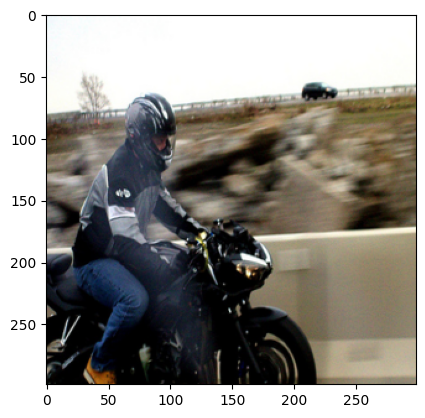

Reference captions: [
An emergency worker uses the jaws of life to cut into an overturned vehicle 
a rescue employee getting ready to pry open a car which has flipped ove
A man is using a device to pry open the door of an overturned blue car 
A Upside down car with rescue worker nearby 
Firefighter cutting a car frame 
]
Generated caption:   a man in a blue shirt is a a .


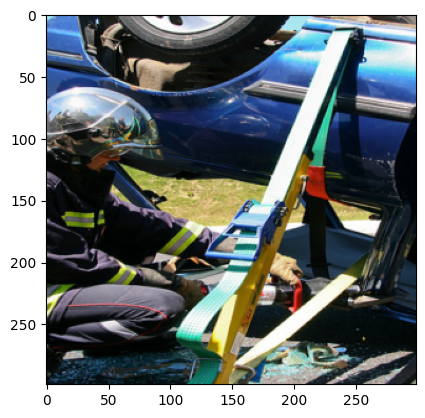

Reference captions: [
The older man with the shopping bag and cane is sitting on a bench 
An old man in a coat and hat sitting on a park bench 
An older man wearing a brown coat siting on a bench 
Old man in tan jacket and black cap sitting on benc
An elderly man is sitting on a bench 
]
Generated caption:   a man is sitting on a bench .


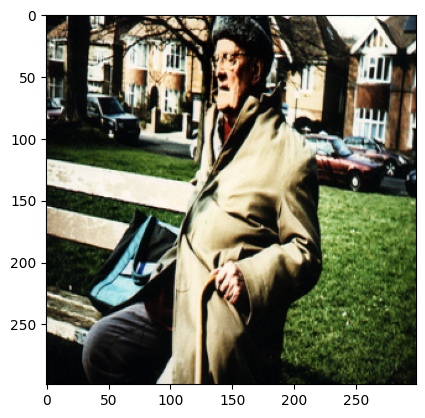

Reference captions: [
A girl tries holding onto a vine so she so n't fall into the water 
The girl is swinging on a rope over a small pond 
Woman swinging above water while holding a vine 
a girl wearfing pink swings over a creek 
A girl swings on a vine over water 
]
Generated caption:   a little girl in a pink shirt is on a swing .


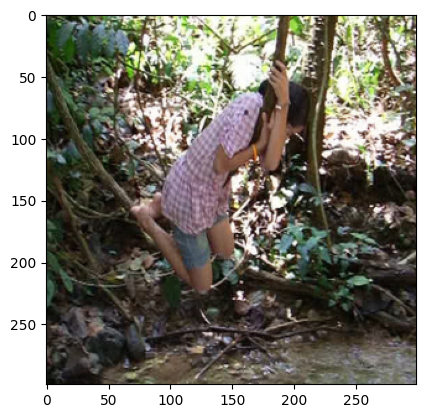

Reference captions: [
A woman is talking on a cellphone on the curb in front of a restaurant 
A woman in a skirt is talking on the phone outside a restaurant 
A woman calling her date , whom appears to be late 
A blond woman is talking on a cellphone 
Woman is talking on a cellphone 
]
Generated caption:   a woman in a blue shirt and a a a a .


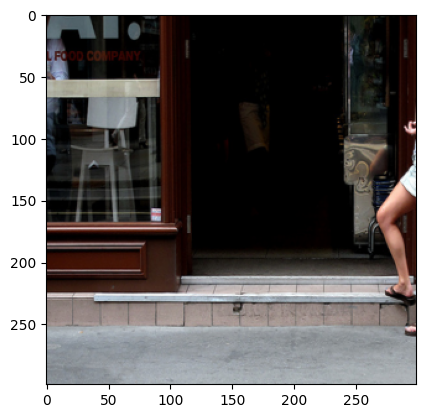

Reference captions: [
The man in black shirt is showing some photo album to others 
A man showing some people pictures in a public place 
A man is standing in a room showing a diagram 
an older man opening a present 
Passengers on a moving train 
]
Generated caption:   a man sitting on a bus .


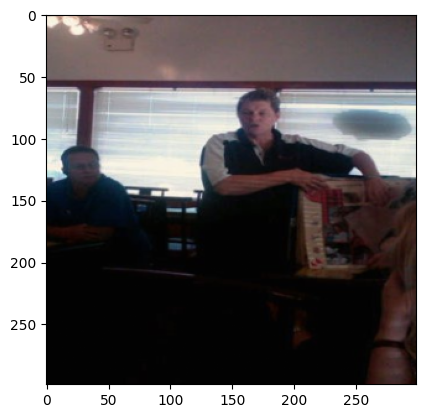

Reference captions: [
A small boy runs barefoot on a concrete surface while holding a racket 
A child holding a tennis racquet running on a tennis court 
A young boy playing tennis on a wet court with no shoes 
A child runs barefoot across a blacktop parking lot 
Boy running along court with tennis racket 
]
Generated caption:   a man in a red shirt and blue jeans is walking down a street .


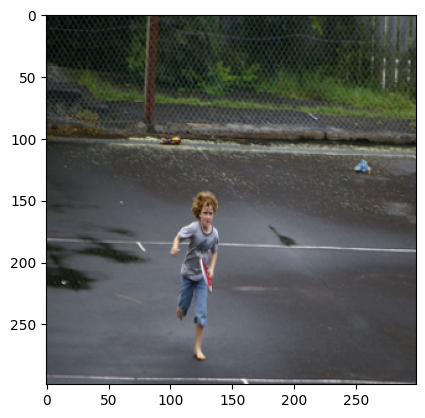

Reference captions: [
Four ballerinas wearing a black sleeveless shirt , gray skirt , and white pantyhose are standing on their toes while lifting their arms 
Four females stand on the tip of their toes while practicing ballet in front of a black backdrop 
There are four synchronized ballerinas completing their show 
Four ballerinas dancing on stage 
Four girls are in a ballet 
]
Generated caption:   four dancers are performing a stage .


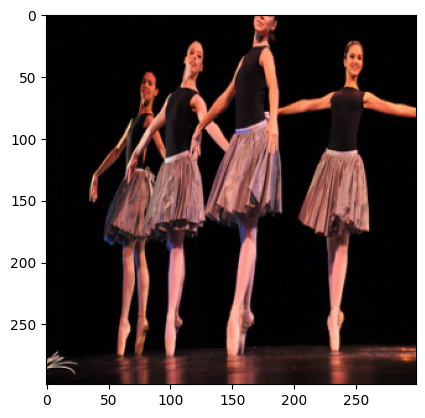

Reference captions: [
Construction workers are unloading bricks from a truck parked directly across from the work area where another worker waits 
Construction workers stand in a street attempting to move bricks 
Workers moving bricks from a white and green truck 
A construction crew on site near a work truck 
Not appearing within my field of vision 
]
Generated caption:   a man in a blue shirt is a a .


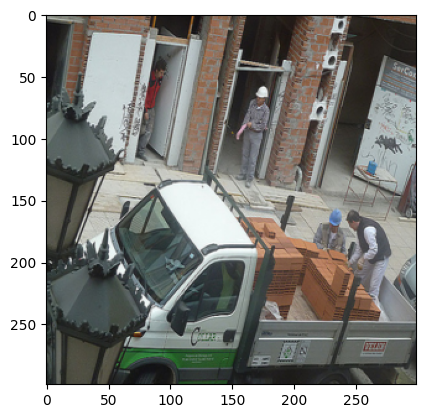

Reference captions: [
Person on snow skis airborne over snow with green tree in the background 
The skier is jumping over a snowy mound in front of a pine tree 
This person is jumping off of a hill while skiing 
A person on skis is jumping a small hill 
A skier is airborne in front of a tree 
]
Generated caption:   a man in a red helmet is a a .


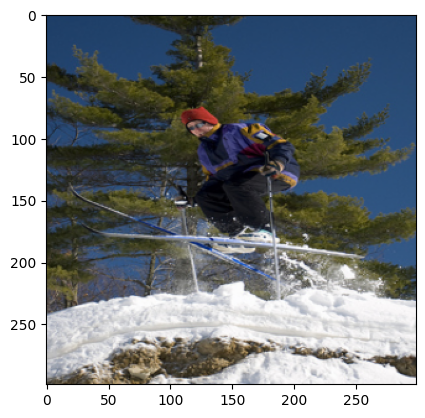

Reference captions: [
African grocery market , with lady shopping for vegetables and fruits 
Some Africans are shopping at an open air market for green vegetables 
Many people are doing business at a farmer 's market 
Black people talking in the marketplace 
Customers shopping in a food kiosk 
]
Generated caption:   a large group of people are gathered in a market .


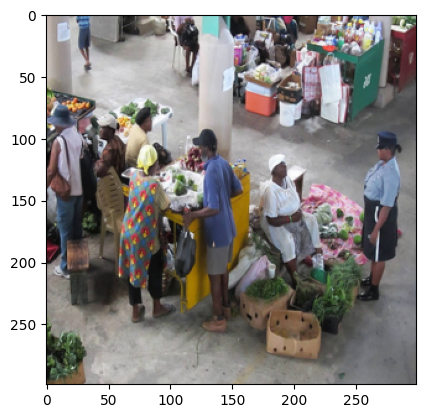

Reference captions: [
A young man with brown hair , a black shirt , and a backpack is holding a sign that reads " Class war , Wanker . 
A male youth in black clothing carries a backpack with a protest sign in it 
A man with a backpack is walking with a " Class War Wanker " sign 
Teenage boy looking over his shoulder during a social event 
man with a backpack with sigh hanging from i
]
Generated caption:   a man in a black jacket is a a a .


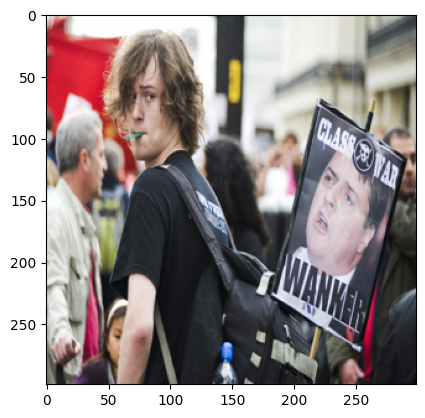

Reference captions: [
A blond woman in a leather jacket is sitting outside with a man in a blue and red jacket , and there is a dog between them 
A man and a woman are sitting at a table , accompanied by a dog , at the edge of a street 
Two people eating at an outside table with their dog 
two people eating with an onlooking greyhound dog 
A dog begging to a man and a woman 
]
Generated caption:   a woman is sitting on a bench .


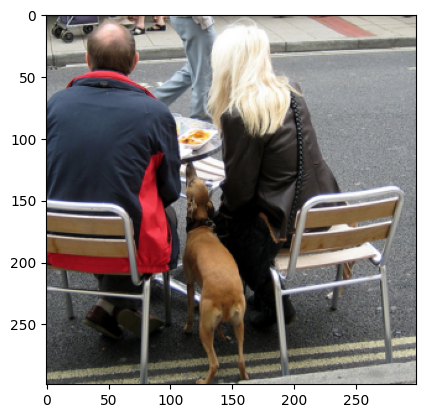

Reference captions: [
Two dogs are playing with each other on a beach by the ocean 
Two big German Shepherd dogs play in the water 
Two black dogs splash around on the beach 
Two dogs play together splashing in a lak
Two dogs playing in water on the beac
]
Generated caption:   two dogs run through the water .


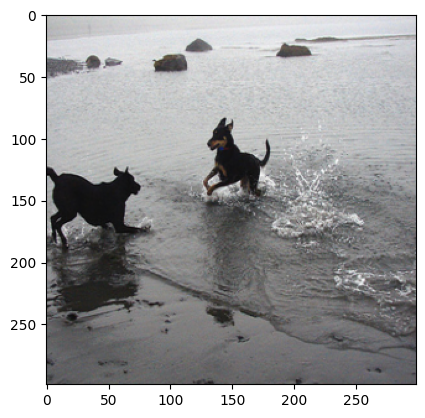

Reference captions: [
A man in glasses wearing a military style cap and a jacket with medals is waving his right hand and sits in front of another waving man in military dress 
A man 's upper torso in Union Blue waving with a flag in background and Confederate Gray behind him waving as well 
A man that is wearing a gray military shirt with medals and a light blue cap with gold on it is waving his arm 
A man with glasses and a beard dressed in a union soldier uniform , waving 
A man in a blue shirt has one hand in a raised position 
]
Generated caption:   a man wearing a black hat and a a .


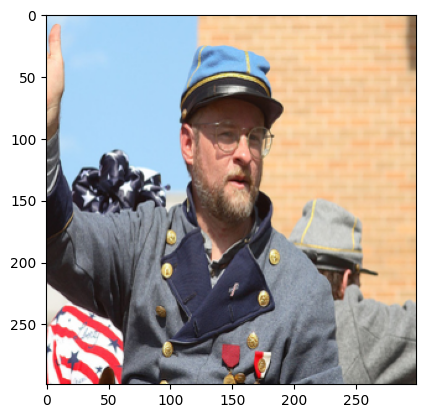

Reference captions: [
Guy in jeans and black jacket walking along grass and trees with the city in the background 
A man is walking down the street wearing blue jeans and carrying some bags 
A man in a black jacket and blue jeans is walking outside on the sidewalk 
A man is walking down the sidewalk next to a street 
People walking along a city street 
]
Generated caption:   a man is walking down the street .


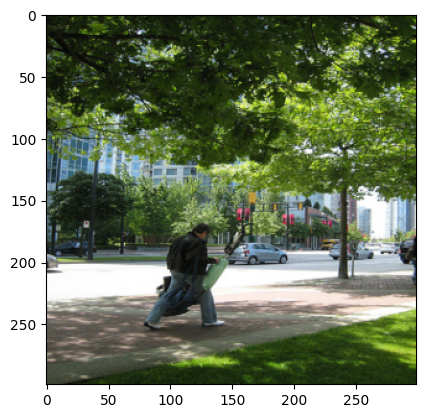

BLEU Score: 0.5855965237660847


In [48]:
# Parameters
embed_size = params['embed_size']
hidden_size = params['hidden_size']
vocab_size = params['vocab_size']
num_layers = params['num_layers']

mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])
captions_dict = CaptionsDict()
captions_dict.get_captions_dict("/kaggle/working/new_results.csv")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers)

# Load model
checkpoint = torch.load('/kaggle/working/checkpoint_20.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
i = 0

model.eval()
with torch.no_grad():
    
    # Testing using BLEU score
    reference_captions = []
    generated_captions = []

    for imgs, captions, img_id in test_loader:
        
        # Using only the first image since the test loader's batch size is 1
        img = imgs[0].to(device)
        
        generated_caption = model.caption_image_beam_search(img, train_dataset.vocab)
        generated_caption = ' '.join(generated_caption)
        
        reference_captions.append(captions_dict.get_reference_captions(img_id[0]))
        generated_captions.append(generated_caption)

        if i % 1500 == 0:
            print("Reference captions: [")
            for r_cap in captions_dict.get_reference_captions(img_id[0]):
                print(r_cap, end='\n')
            print("]\nGenerated caption:", generated_caption)
            display_img = img.cpu()
            display_img = display_img * std[:, None, None] + mean[:, None, None]
            plt.imshow(display_img.permute(1, 2, 0))
            plt.show()

        i += 1

# Calculating BLEU Score
smooth_fn = SmoothingFunction().method4
bleu = corpus_bleu(reference_captions, generated_captions, smoothing_function=smooth_fn)
print(f"BLEU Score: {bleu}")

# Inference

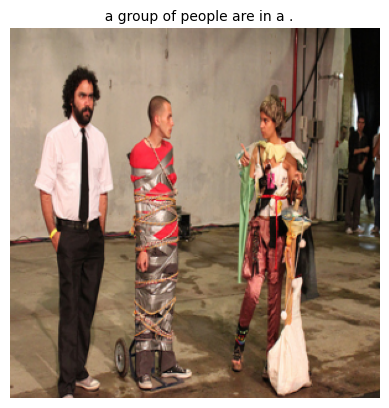

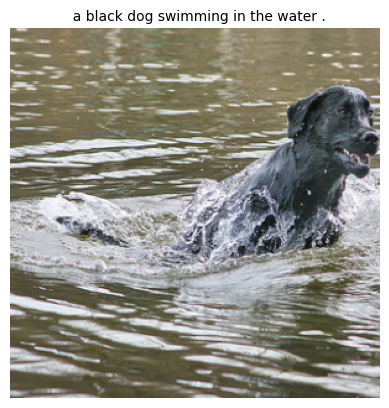

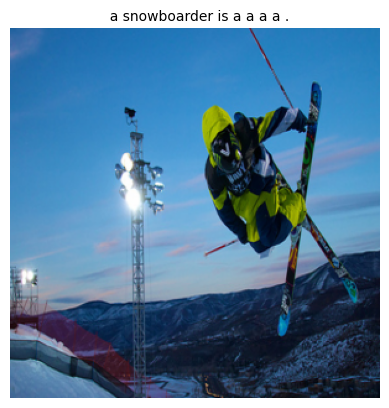

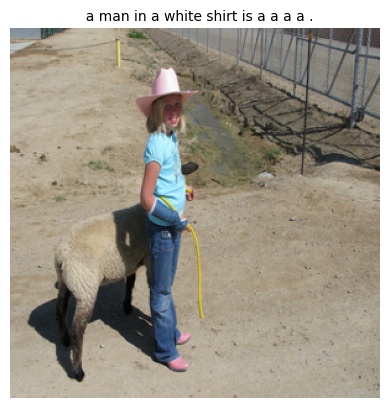

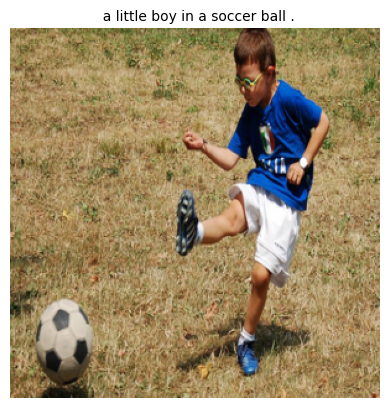

In [54]:
mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])

for i, (imgs, captions, img_id) in enumerate(test_loader):
    if i < 5:
        img = imgs[0].to(device)
    
        generated_caption = model.caption_image_beam_search(img, train_dataset.vocab)
    
        display_img = img.cpu()
        display_img = display_img * std[:, None, None] + mean[:, None, None]
        
        plt.imshow(display_img.permute(1, 2, 0))
        plt.axis('off')
        plt.title(' '.join(generated_caption), fontsize=10)
        plt.show()
    
    else:
        break